#**Sales Forecasting Across Multiple Retail Stores**

**NOTEBOOK-1**

**Name** : Bindu Kale A  
**Dataset** : store.csv  
**Organisation** : NextHikes IT Solutions   
**File Name** : Cleaned_Store  
**Submission Date** : September 15 2026  
**Project** : Sales Forecasting

**INTRODUCTION**

Rossmann is a large European drugstore chain operating thousands of stores across multiple countries. Store managers are currently responsible for forecasting daily sales up to six weeks in advance, relying largely on personal experience and judgment. These forecasts are often inconsistent and vary widely in accuracy.
The finance team at Rossmann needs a reliable, data-driven solution that can predict sales across all stores in a consistent and scalable way. Accurate sales forecasts help the company plan inventory, optimize staffing, design better promotions, and improve overall operational efficiency.
This project aims to build an end-to-end machine learning solution that forecasts daily sales for Rossmann stores six weeks ahead, using historical sales data, promotional information, competitor data, holidays, and store characteristics.

**OBJECTIVES**

* Explore customer purchasing behaviour- Perform a thorough exploratory data analysis to understand how promotions, holidays, seasonality, assortment, competition, and store type influence sales and customer footfall.

* Build accurate sales prediction models- Develop machine learning models (starting with tree-based models such as Random Forest, and later deep learning approaches like LSTM) that can forecast daily sales up to six weeks ahead.

* Create a robust and reproducible pipeline- Implement proper data preprocessing, feature engineering, encoding, scaling, and modelling using scikit-learn pipelines so that the solution is modular, reproducible, and easy to deploy.

* Evaluate and interpret model performance- Select appropriate loss functions (e.g., MAE, RMSE, MAPE), analyse feature importance, and estimate prediction confidence.

* Deploy the solution- Serve the trained model through a web interface (Streamlit / Flask) so that store managers and finance analysts can easily input data and obtain sales forecasts along with customer predictions.

**Libraries Imported**

In [1]:
import pandas as pd
import numpy as np
import logging
import sys

In [2]:
LOG_FILE = 'load_clean_store.log'
logger = logging.getLogger('load_clean_store')
logger.setLevel(logging.DEBUG)
logger.propagate = False

* This helps to prepare a named logger to record detailed program activity.

In [3]:
if not logger.handlers:
    formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(formatter)

    file_handler = logging.FileHandler(LOG_FILE)
    file_handler.setLevel(logging.DEBUG)
    file_handler.setFormatter(formatter)

    logger.addHandler(console_handler)
    logger.addHandler(file_handler)

pd.set_option('display.max_columns', None)
logger.info(f"Libraries imported and logger configured. Full detail is being written to {LOG_FILE}")

2026-09-15 19:17:50,036 - load_clean_store - INFO - Libraries imported and logger configured. Full detail is being written to load_clean_store.log


* The libraries were imported successfully, the logger was configured, and detailed logs are being saved in load_clean_store.log

**Loading Store Data**

In [4]:
store = pd.read_csv('store.csv')
logger.info(f"store.csv loaded successfully. Shape: {store.shape}")
logger.debug(f"store.csv dtypes: {dict(store.dtypes.astype(str))}")   # ← new line
store.head()

2026-09-15 19:17:50,304 - load_clean_store - INFO - store.csv loaded successfully. Shape: (1115, 10)


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


* The output confirms that store.csv was loaded successfully. The dataset contains 1,115 rows and 10 columns.

* The displayed table shows the first five records, including store type, assortment, competition distance, and promotion details. Missing /
values are represented by NaN.

In [5]:
#Dataset Information
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 98.0 KB


* There are 5 numerical columns of type float64, 2 integer columns, and 3 categorical columns of type object.

* Some columns contain missing values, particularly CompetitionOpenSinceMonth, CompetitionOpenSinceYear, Promo2SinceWeek, Promo2SinceYear, and PromoInterval.

**DATA PREPROCESSING**

In [6]:
#Checking for missing values
logger.info("Checking missing values per column")
missing = store.isnull().sum()
missing_pct =(missing/len(store)* 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

2026-09-15 19:17:50,513 - load_clean_store - INFO - Checking missing values per column


,missing_count,missing_pct
CompetitionDistance,3,0.27
CompetitionOpenSinceMonth,354,31.75
CompetitionOpenSinceYear,354,31.75
Promo2SinceWeek,544,48.79
Promo2SinceYear,544,48.79
PromoInterval,544,48.79


* The output shows the missing values in each column. CompetitionDistance has only 3 missing values (0.27%), while the competition opening details have 354 missing values (31.75%).

* The promotion-related columns have 544 missing values (48.79%), indicating a significant amount of missing data that needs to be handled during data cleaning.

In [7]:
# Checking for Duplicate Values
logger.info(f"Duplicate rows in store: {store.duplicated().sum()}")

2026-09-15 19:17:50,587 - load_clean_store - INFO - Duplicate rows in store: 0


* There are 0 duplicate rows in the store dataset. This means all 1,115 records are unique, so no duplicate records need to be removed.

In [8]:
store.describe(include='all')

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
count,1115.00000,1115,1115,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000,571
unique,NaN,4,3,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,a,a,NaN,NaN,NaN,NaN,NaN,NaN,"Jan,Apr,Jul,Oct"
freq,NaN,602,593,NaN,NaN,NaN,NaN,NaN,NaN,335
mean,558.00000,NaN,NaN,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573,NaN
std,322.01708,NaN,NaN,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935,NaN
min,1.00000,NaN,NaN,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000,NaN
25%,279.50000,NaN,NaN,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000,NaN
50%,558.00000,NaN,NaN,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000,NaN
75%,836.50000,NaN,NaN,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000,NaN


* The descriptive statistics show the distribution of the store dataset.

* There are 1,115 stores, with StoreType a being the most common (602 stores) and Assortment a being the most frequent (593 stores).

* The average CompetitionDistance is about 5,405 meters. Approximately 51% of stores have Promo2 enabled.

* The statistics also show missing values in several columns, which need to be handled during data cleaning.

**Handling Missing Values**

In [9]:
# Sanity check- to confirm Promo2SinceWeek is missing exactly when Promo2 == 0
check = store[store['Promo2'] == 0]['Promo2SinceWeek'].isnull().sum()
total_promo2_zero = (store['Promo2'] == 0).sum()
logger.info(f"Stores with Promo2==0: {total_promo2_zero}, of which Promo2 Since Week is missing: {check}")
assert check == total_promo2_zero, "Mismatch — investigate further before blindly filling with 0"

2026-09-15 19:17:50,766 - load_clean_store - INFO - Stores with Promo2==0: 544, of which Promo2 Since Week is missing: 544


* Here we can see that 544 stores have Promo2 = 0, meaning they are not participating in the promotion. For all these 544 stores, Promo2SinceWeek is missing.

* This is expected as the stores without Promo2 do not have a promotion start week.

In [10]:
#Fixing Competition Distance
median_dist = store['CompetitionDistance'].median()
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(median_dist)
logger.info(f"Filled {3} missing Competition Distance values with median = {median_dist}")

2026-09-15 19:17:50,796 - load_clean_store - INFO - Filled 3 missing Competition Distance values with median = 2325.0


* The 3 missing values in CompetitionDistance were replaced with the median value of 2,325. This further ensures there are no missing values in this column.

In [11]:
#Fixing CompetitionOpenSinceMonth / Year
store['CompetitionOpenSinceKnown'] = store['CompetitionOpenSinceMonth'].notnull().astype(int)
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0).astype(int)
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(0).astype(int)
logger.info("Filled Competition Open Since Month/Year with 0 and added Competition Open Since Known flag.")

2026-09-15 19:17:50,833 - load_clean_store - INFO - Filled Competition Open Since Month/Year with 0 and added Competition Open Since Known flag.


* The output shows that missing Competition Open Since Month/Year values were replaced with 0.

* A new flag, CompetitionOpenSinceKnown, was also added to indicate whether the original competition opening information was available.

In [12]:
# Fixing Promo2SinceWeek / Year / PromoInterval
store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(0).astype(int)
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(0).astype(int)
store['PromoInterval'] = store['PromoInterval'].fillna('NoPromo2')
logger.info("Filled Promo2 Since Week/Year with 0 and PromoInterval with 'NoPromo2'.")

2026-09-15 19:17:50,866 - load_clean_store - INFO - Filled Promo2 Since Week/Year with 0 and PromoInterval with 'NoPromo2'.


* The missing values of Promo2SinceWeek and Promo2SinceYear values were replaced with 0, while missing PromoInterval values were replaced with NoPromo2. This indicates that these stores were not participating in Promo2.

In [13]:
# Verifying for no missing values
remaining_missing = store.isnull().sum().sum()
logger.info(f"Total remaining missing values in store data: {remaining_missing}")
assert remaining_missing == 0, "Still missing values — check above steps"
store.isnull().sum()

2026-09-15 19:17:50,890 - load_clean_store - INFO - Total remaining missing values in store data: 0


Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
CompetitionOpenSinceKnown    0
dtype: int64

* This confirms that all missing values in the store dataset have been successfully handled. The total number of remaining missing values is 0, meaning the dataset is now complete and ready for further analysis

In [14]:
# Handling Data Types
categorical_cols = ['StoreType', 'Assortment', 'PromoInterval']
for col in categorical_cols:
    store[col] = store[col].astype('category')

logger.info(f"Converted {categorical_cols} to category dtype.")
store.dtypes

2026-09-15 19:17:50,942 - load_clean_store - INFO - Converted ['StoreType', 'Assortment', 'PromoInterval'] to category dtype.


Store                           int64
StoreType                    category
Assortment                   category
CompetitionDistance           float64
CompetitionOpenSinceMonth       int64
CompetitionOpenSinceYear        int64
Promo2                          int64
Promo2SinceWeek                 int64
Promo2SinceYear                 int64
PromoInterval                category
CompetitionOpenSinceKnown       int64
dtype: object

* Here we have converted- StoreType, Assortment, and PromoInterval from object type to categorical data type.

2026-09-15 19:17:50,987 - load_clean_store - INFO - count     1115.000000
mean      5396.614350
std       7654.513635
min         20.000000
25%        720.000000
50%       2325.000000
75%       6875.000000
max      75860.000000
Name: CompetitionDistance, dtype: float64


<Axes: title={'center': 'CompetitionDistance spread (store level)'}>

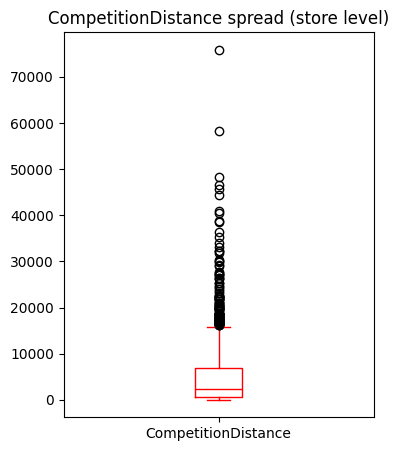

In [15]:
# Outlier Checking
logger.info(store['CompetitionDistance'].describe())
store['CompetitionDistance'].plot(kind='box', title='CompetitionDistance spread (store level)', figsize=(4,5), color='red')

* The result shows the distribution of CompetitionDistance across 1,115 stores.

* The average distance is approximately 5,397 meters, while the median is 2,325 meters.

* The large difference between the mean and median indicates that the data is right-skewed, with some stores having very large competition distances. The graph visualizes this spread.

**Save Cleaned Data**

In [16]:
output_path = 'cleaned_store.csv'
store.to_csv(output_path, index=False)
logger.info(f"Cleaned store data saved to {output_path}. Final shape: {store.shape}")

2026-09-15 19:17:56,433 - load_clean_store - INFO - Cleaned store data saved to cleaned_store.csv. Final shape: (1115, 11)


* The cleaned store data was successfully saved as cleaned_store.csv. The final dataset contains 1,115 rows and 11 columns, with the additional column created during the data-cleaning process.

In [17]:
# Confirming the saved data
_reloaded = pd.read_csv(output_path)
_reloaded_nulls = _reloaded.isnull().sum().sum()
logger.info(f"Round-trip check — nulls after reloading saved CSV: {_reloaded_nulls}")
assert _reloaded_nulls == 0, "Nulls reappeared after save/reload — check for values pandas treats as NA (e.g. the string 'None')"

store.head()

2026-09-15 19:17:56,459 - load_clean_store - INFO - Round-trip check — nulls after reloading saved CSV: 0


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionOpenSinceKnown
0,1,c,a,1270.0,9,2008,0,0,0,NoPromo2,1
1,2,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct",1
2,3,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct",1
3,4,c,c,620.0,9,2009,0,0,0,NoPromo2,1
4,5,a,a,29910.0,4,2015,0,0,0,NoPromo2,1


* The output confirms that the cleaned CSV was successfully reloaded and contains 0 missing values. This verifies that the data-cleaning process was preserved correctly after saving and reloading the file.

In [18]:
from google.colab import files

files.download('cleaned_store.csv')


ModuleNotFoundError: No module named 'google.colab'

* This code helps to download the cleaned_store.csv file from Google Colab to the local computer.